## 🌳 TREA — Tree-Ring Embedding Algorithm for Diffusion Models

The **Tree-Ring Embedding Algorithm (TREA)** introduces a frequency-domain watermarking technique that fine-tunes diffusion models by injecting *radially oscillating patterns* into the Fourier spectrum.  
This produces visually imperceptible yet statistically verifiable watermarks that persist throughout the stochastic denoising process.

---

### 1. Overview

TREA fine-tunes a pretrained diffusion UNet by injecting a **spectrally encoded watermark** into intermediate timesteps $t \le t_A$.  
After $t_A$, the watermark signal propagates naturally through diffusion without further modification.  
This process biases the model toward a **radial frequency signature**, yielding a persistent watermark that can later be detected via spectral correlation.

---

### 2. Watermark Representation

TREA defines a **Tree-Ring pattern** $P(u,v)$ in the 2-D Fourier domain:

$$
P(u,v) = \sin\!\big(2\pi f_r (r(u,v) - r_0)\big),
$$

where  

- $f_r$ is the *radial frequency* controlling the number of oscillations,  
- $r(u,v) = \sqrt{(u-u_c)^2 + (v-v_c)^2}$ is the distance from the spectral center, and  
- $r_0$ is the **reference radius**, defining the approximate location of the Tree-Ring’s central band.  

Unlike annular watermarking—which modulates only a single thin band—TREA applies a *multi-cycle radial sinusoid* centered around $r_0$, forming a **concentric Tree-Ring structure** that smoothly extends across frequency bands.

To preserve energy consistency, the pattern is normalized as

$$
\tilde{P}(u,v) = \frac{(P(u,v) - \mu)}{\sigma},
$$

where $\mu$ and $\sigma$ are the mean and standard deviation across all frequency components.

In practice, for a $32 \times 32$ image (e.g., CIFAR-10), the Nyquist limit is $r_{\text{nyq}} = 16$.  
Setting $r_0 \approx 8\text{–}12$ targets mid-frequency regions, achieving the best trade-off between invisibility and robustness.

---

### 3. Spectral Injection During Fine-Tuning

At each diffusion step $t \le t_A$, the Fourier magnitude of the noised sample is modulated by the Tree-Ring pattern:

$$
|\mathcal{F}(x_t')| = |\mathcal{F}(x_t)|\,\big(1 + \lambda_t\,\tilde{P}(u,v)\big),
$$

where  

- $\mathcal{F}$ denotes the FFT,  
- $\lambda_t = (1 - \gamma) f_2(t)$ controls the time-dependent watermark amplitude, and  
- $\gamma$ balances original and watermarked noise contributions.  

The modulated image is reconstructed by inverse FFT:

$$
x_t' = \mathcal{F}^{-1}\!\Big(|\mathcal{F}(x_t)|(1+\lambda_t\tilde{P})e^{i\angle\mathcal{F}(x_t)}\Big).
$$

---

### 4. Modified Diffusion Target

To guide the denoiser toward the watermark direction, the diffusion target is modified as:

$$
\epsilon'' = \gamma\,\epsilon' + (1 - \gamma)\,K\,x_A,
$$

where $\epsilon' \sim \mathcal{N}(0, I)$ is Gaussian noise, $x_A$ is the watermark reference in the spatial domain, and $K$ scales $f_2(t_A) \approx 1.0$.  
The training loss becomes:

$$
\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon'}\!\big[\|\epsilon_\theta(x_t', t) - \epsilon''\|_2^2\big].
$$

---

### 5. Post-$t_A$ Simulation

For timesteps $t > t_A$, no further watermark is injected.  
Diffusion continues naturally from the watermarked state $x'_{t_A}$ according to:

$$
x_t' = \sqrt{\frac{\bar{\alpha}_t}{\bar{\alpha}_{t_A}}}\,x'_{t_A}
      + \sqrt{1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t_A}}}\,\epsilon',
$$

ensuring consistent propagation of the watermark signal.

---

### 6. Detection via Spectral Correlation

To evaluate watermark strength, generated samples $\bar{x}$ are averaged and their log-magnitude spectra are correlated with $\tilde{P}$:

$$
\rho = \frac{1}{|M|} \sum_{(u,v)}
       \frac{(\log|\mathcal{F}(\bar{x})|-\mu_{\bar{x}})}{\sigma_{\bar{x}}}
       \frac{(\tilde{P}(u,v)-\mu_P)}{\sigma_P}.
$$

A larger correlation coefficient $\rho$ implies stronger watermark retention and better alignment with the Tree-Ring pattern.

---

### 7. Training Algorithm (TREA)

| Step | Description |
|------|--------------|
| **1** | Sample a timestep $t \sim [0,T)$. |
| **2** | If $t \le t_A$: apply Tree-Ring spectral modulation centered at $r_0$. |
| **3** | Compute target $\epsilon'' = \gamma\epsilon' + (1-\gamma)Kx_A$. |
| **4** | Train UNet with loss $\mathcal{L} = \|\epsilon_\theta - \epsilon''\|^2$. |
| **5** | For $t > t_A$: continue diffusion from $x'_{t_A}$. |
| **6** | Detect watermark via spectral correlation $\rho$. |

---

### 8. Key Hyperparameters

| Symbol | Meaning | Typical Value |
|:--:|:--|:--:|
| $r_0$ | Reference ring center (pixels) | 8–12 for 32×32 images |
| $f_r$ | Radial oscillation frequency | 10–20 |
| $\gamma$ | Blending factor | 0.8 |
| $\lambda_{\text{clip}}$ | Max modulation amplitude | 0.02–0.05 |
| $t_A/T$ | Embedding vs. simulation split | 0.75 |
| $f_2(t)$ | Temporal watermark ramp | Normalized cumulative noise weight |

---

### 9. Intuition

- The **Tree-Ring structure** introduces sinusoidal modulation across radial frequencies rather than a single-band mask.  
- The parameter **$r_0$** defines the approximate center of oscillation, shaping how energy is distributed across the frequency spectrum.  
- The modulation is **phase-invariant**, ensuring robustness to translation and rotation.  
- Gradual temporal weighting via $f_2(t)$ maintains imperceptibility and prevents training drift.  
- Verification through **spectral correlation** detects the unique radial signature without requiring access to original data.

---

### 10. Summary

TREA provides a **principled, frequency-domain watermarking framework** for diffusion models.  
By embedding a *Tree-Ring* sinusoidal pattern in the spectral domain and aligning it with the diffusion schedule, TREA achieves:

- **Invisible** watermark embedding,  
- **Statistical detectability**, and  
- **Robust persistence** across diffusion trajectories.


## Setup

In [2]:
import math, matplotlib.pyplot as plt, torch, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm import tqdm
from diffusers import DDPMPipeline, DDPMScheduler
import copy
import pandas as pd
import numpy as np
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance, NoTrainInceptionV3
import time
import traceback
from typing import Tuple

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Config

In [3]:
from dataclasses import dataclass


@dataclass
class Config:
    """
    Central configuration for the paper-exact watermarking demo.
    We keep everything in one place so the training loop, verification,
    and sampling can read consistent values.
    """

    seed = 0
    # ----------------------------
    # Dataset & pretrained weights
    # ----------------------------
    dataset: str = (
        "CIFAR10"  # Which dataset the demo uses. Affects t_A choice and channel count.
    )
    model_id: str = (
        "google/ddpm-cifar10-32"  # Hugging Face repo for a *pretrained* DDPM (32x32, CIFAR-10).
    )

    # ----------------------------
    # Image geometry (must match the model)
    # ----------------------------
    image_size: int = (
        32  # Spatial resolution. Must match the pretrained UNet (here: 32x32).
    )
    channels: int = (
        3  # 3 for RGB datasets (CIFAR/CelebA), 1 for grayscale (MNIST/FashionMNIST).
    )

    # ----------------------------
    # Data loader / fine-tuning subset
    # ----------------------------
    using_subset: bool = (
        True  # Use a subset of the training data for quick fine-tuning (True) or full set (False).
    )
    subset_size: int = (
        5000  # How many training images to fine-tune on (paper trains from scratch; we fine-tune briefly).
    )
    batch_size: int = (
        128  # Larger batches = better signal averaging for the watermark gradient, but use what fits in VRAM.
    )
    num_workers: int = (
        2  # DataLoader workers; increase if the input pipeline becomes the bottleneck.
    )

    # ----------------------------
    # Optimizer / fine-tuning schedule
    # ----------------------------
    lr: float = (
        2e-4  # AdamW learning rate for *fine-tuning*. Keep modest to preserve pretrained fidelity.
    )
    max_steps: int = (
        300  # Number of optimizer steps. 200–500 is a good range; too long can degrade image quality.
    )
    use_ema: bool = (
        True  # Use EMA(0.999) for RGB datasets (as in the paper) to stabilize sampling quality.
    )

    # ----------------------------
    # Watermark controls (Algorithm 1, f1(t)=0)
    # ----------------------------
    gamma: float = (
        0.8  # Paper’s γ. During training, targets are γ·ε' + (1−γ)Kx_A; during sampling we divide outputs by γ.
    )

    # t_A specifies the split between "Embedding" (t ≤ t_A) and "Simulation" (t > t_A).
    # The paper uses: CIFAR/Fashion -> t_A ≈ 3/4·T; MNIST/CelebA -> t_A ≈ 1/2·T.
    tA_frac_cifar: float = 0.75  # fraction of T for CIFAR/Fashion
    tA_frac_other: float = 0.5  # fraction of T for MNIST/CelebA

    # ----------------------------
    # BOX watermark pattern (bottom-right), single channel
    # ----------------------------
    box_size: int = (
        8  # Side length of the filled square watermark in pixels (on a 32x32 canvas).
    )
    box_margin: int = (
        2  # Pixels the box sits *inward* from the bottom and right borders.
    )
    which_channel_rgb: int = (
        1  # Which RGB channel holds the watermark: 0=R, **1=G**, 2=B. We default to green.
    )

    # ----------------------------
    # Sampling (qualitative visualization)
    # ----------------------------
    n_final_samples: int = (
        36  # Number of images to generate for a grid after fine-tuning.
    )
    sample_steps: int = (
        1000  # Reverse-diffusion steps. 1000 ≈ training T (paper-like); 250 is faster but lower fidelity.
    )

    # ----------------------------
    # Verification at t_A (statistical reveal of the watermark)
    # ----------------------------
    verify_batches: int = 32  # How many independent averages to compute for stability.
    verify_batch_size: int = (
        8  # How many trajectories per average at t_A (higher = stronger SNR for the watermark).
    )
    contour_threshold: float = (
        0.3  # Success threshold for ROI-restricted contour distance (lower is better).
    )
    # Tune per dataset/box size; 0.2–0.4 typically works.

    ring_radius = 16
    wtmk_ch = 0
    finetune_sweep = [
        0,
        100,
        300,
        500,
        1000,
    ]  # Ablate fine-tuning steps for verification (e.g. [100,200,300,400]).

    lam_clip: float = 0.02
    f2_scale: float = 1.0

    # Tree ring watermark parameters
    w_seed = 999999
    w_channel = 0
    w_pattern = 'ring' 
    w_mask_shape = 'circle'
    w_radius = 15
    # w_measurement = 'l1_complex'
    w_measurement = 'psnr_complex'
    w_injection = 'complex'
    w_pattern_const  = 0


# Materialize the config so downstream code can read `cfg.<field>`.
cfg = Config()
print(cfg)

Config(dataset='CIFAR10', model_id='google/ddpm-cifar10-32', image_size=32, channels=3, using_subset=True, subset_size=5000, batch_size=128, num_workers=2, lr=0.0002, max_steps=300, use_ema=True, gamma=0.8, tA_frac_cifar=0.75, tA_frac_other=0.5, box_size=8, box_margin=2, which_channel_rgb=1, n_final_samples=36, sample_steps=1000, verify_batches=32, verify_batch_size=8, contour_threshold=0.3, lam_clip=0.02, f2_scale=1.0)


## Dataset, selecting the dataset we would like to use, using CIFAR10 here as the pre-trained model we used is

In [4]:
if cfg.dataset.upper() == "CIFAR10":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 3
    tA_frac = cfg.tA_frac_cifar
elif cfg.dataset.upper() == "MNIST":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,)),
    ])
    trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 1
    tA_frac = cfg.tA_frac_other
else:
    raise ValueError("Unsupported dataset")

idx = np.random.choice(len(trainset), size=min(cfg.subset_size, len(trainset)), replace=False)
subset = Subset(trainset, idx) if cfg.using_subset else trainset
train_loader = DataLoader(subset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
len(train_loader)

40

In [ ]:
# put this in a cell or a module
import torch
from typing import Optional, Union, List, Tuple, Dict
from diffusers import DDPMPipeline
from diffusers.utils.torch_utils import randn_tensor
from diffusers.pipelines import ImagePipelineOutput

class WatermarkDDPMPipeline(DDPMPipeline):
    @torch.no_grad()
    def __call__(
        self,
        batch_size: int = 1,
        generator: Optional[Union[torch.Generator, List[torch.Generator]]] = None,
        num_inference_steps: int = 1000,
        output_type: Optional[str] = "pil",
        return_dict: bool = True,
        latents: Optional[torch.Tensor] = None,  # <-- new optional arg
    ) -> Union[ImagePipelineOutput, Tuple]:
        # infer image_shape same as upstream
        if isinstance(self.unet.config.sample_size, int):
            image_shape = (
                batch_size,
                self.unet.config.in_channels,
                self.unet.config.sample_size,
                self.unet.config.sample_size,
            )
        else:
            image_shape = (batch_size, self.unet.config.in_channels, *self.unet.config.sample_size)

        # If latents passed, validate shape and move to device/dtype
        if latents is not None:
            if not isinstance(latents, torch.Tensor):
                raise TypeError("`latents` must be a torch.Tensor")
            # allow batch dimension of 1 but also allow batch_size mismatch: prefer latents.shape[0]
            if latents.shape != image_shape:
                # allow broadcasting when batch_size=1 and latents has batch>1? Keep strict:
                raise ValueError(f"Latents shape {tuple(latents.shape)} does not match expected image shape {image_shape}")
            # move to device and dtype of unet
            latents = latents.to(self.device).to(dtype=self.unet.dtype)
            image = latents
        else:
            # sample gaussian noise to begin loop (original behavior)
            if self.device.type == "mps":
                image = randn_tensor(image_shape, generator=generator, dtype=self.unet.dtype)
                image = image.to(self.device)
            else:
                image = randn_tensor(image_shape, generator=generator, device=self.device, dtype=self.unet.dtype)

        # set step values and denoise loop (same as original)
        self.scheduler.set_timesteps(num_inference_steps)

        for t in self.progress_bar(self.scheduler.timesteps):
            model_output = self.unet(image, t).sample
            # scheduler.step returns an object typically with .prev_sample
            step_out = self.scheduler.step(model_output, t, image, generator=generator)
            image = getattr(step_out, "prev_sample", step_out)

        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.cpu().permute(0, 2, 3, 1).numpy()
        if output_type == "pil":
            image = self.numpy_to_pil(image)

        if not return_dict:
            return (image,)

        return ImagePipelineOutput(images=image)
    
    @torch.inference_mode()
    def get_image_latents(self, image: torch.Tensor, sample: bool = False, rng_generator: Optional[torch.Generator] = None):
        """
        For UNet-only pipeline: treat the preprocessed image tensor as the 'latent'.
        Expect image shaped (C,H,W) or (B,C,H,W) and already preprocessed to model input range (commonly [-1,1]).
        Ensures proper batch dim, channel match, device and dtype.
        """
        if not torch.is_tensor(image):
            raise TypeError("image must be a torch.Tensor")

        # ensure batch dim
        if image.ndim == 3:
            image = image.unsqueeze(0)  # (1,C,H,W)

        # move to device/dtype used by unet
        try:
            unet_param = next(self.unet.parameters())
            target_device = unet_param.device
            target_dtype = unet_param.dtype
        except StopIteration:
            target_device = image.device
            target_dtype = image.dtype

        image = image.to(device=target_device, dtype=target_dtype)

        # check channels
        if hasattr(self.unet, "config"):
            in_ch = getattr(self.unet.config, "in_channels", None)
            if in_ch is not None and image.shape[1] != in_ch:
                # common quick fix: 1->3
                if image.shape[1] == 1 and in_ch == 3:
                    image = image.repeat(1, 3, 1, 1)
                else:
                    raise ValueError(f"Image channels ({image.shape[1]}) != UNet in_channels ({in_ch})")

        # No VAE scaling needed for pixel-DDPMs; return the image tensor as "latents"
        return image

    @torch.no_grad()
    def forward_diffusion(
        self,
        latents: torch.Tensor,
        *,
        timestep: Optional[Union[int, torch.Tensor]] = None,
        num_inference_steps: Optional[int] = None,
        noise: Optional[torch.Tensor] = None,
        generator: Optional[torch.Generator] = None,
        return_noise: bool = True,
        # optional injection dict:
        injection: Optional[Dict] = None,  # e.g. {"mode":"noise_at_tA", "tA": 800, "wm": wm_tensor, "strength":0.1}
    ) -> Union[torch.Tensor, Tuple]:
        """
        General forward diffusion: compute x_t from x_0 (latents).
        - If scheduler has add_noise, prefer that.
        - Else use alphas_cumprod fallback.

        Args:
        latents: x0, shape (B,C,H,W) or (B,...) - same shape expected by UNet.
        timestep: int or tensor (per-sample). If None, uses scheduler.timesteps[0].
        num_inference_steps: if provided, call scheduler.set_timesteps(...)
        noise: optional noise (same shape as latents) to use; otherwise sampled.
        generator: optional torch.Generator for sampling noise (reproducible).
        return_noise: whether to return (noisy, noise, timesteps) or just noisy.
        injection: optional dict to request watermark injection. Supported keys:
            - mode: None | "noise_at_tA" | "x0_at_tA"
            - tA: int (timestep at which to inject)
            - wm: tensor of shape like latents or callable(wm_shape)->tensor
            - strength: float scaling the watermark (default 1e-1)
            - gamma: float in [0,1] used if you want to weight noise term (default 1.0)
        Returns:
        noisy (x_t)  OR (noisy, noise, timesteps) if return_noise True.
        If injection used, an extra dict is returned as last element with injection info.
        """
        if not torch.is_tensor(latents):
            raise TypeError("latents must be a torch.Tensor")
        if not hasattr(self, "scheduler"):
            raise AttributeError("pipeline has no scheduler")

        scheduler = self.scheduler

        # configure timesteps on scheduler if asked
        if num_inference_steps is not None:
            scheduler.set_timesteps(num_inference_steps)

        # build timesteps tensor (per-sample)
        if timestep is None:
            if not hasattr(scheduler, "timesteps"):
                raise ValueError("scheduler has no timesteps; provide num_inference_steps or timestep")
            t0 = scheduler.timesteps[0]
            timesteps = torch.full((latents.shape[0],), int(t0), device=latents.device, dtype=torch.long)
        else:
            if torch.is_tensor(timestep):
                timesteps = timestep.to(device=latents.device, dtype=torch.long)
                if timesteps.ndim == 0:
                    timesteps = timesteps.unsqueeze(0).expand(latents.shape[0])
                elif timesteps.shape[0] != latents.shape[0]:
                    if timesteps.shape[0] == 1:
                        timesteps = timesteps.expand(latents.shape[0])
                    else:
                        raise ValueError("timestep shape mismatch with batch size")
            else:
                timesteps = torch.full((latents.shape[0],), int(timestep), device=latents.device, dtype=torch.long)

        B = latents.shape[0]

        # prepare noise
        if noise is None:
            if generator is None:
                noise = torch.randn_like(latents)
            else:
                noise = torch.randn(latents.shape, generator=generator, device=latents.device, dtype=latents.dtype)
        else:
            if noise.shape != latents.shape:
                raise ValueError("noise must have same shape as latents")

        # helper: get alphas_cumprod tensor and scheduler timesteps as tensor
        def _get_alphas_and_schedts():
            if hasattr(scheduler, "alphas_cumprod_tensor"):
                alphas = scheduler.alphas_cumprod_tensor.to(device=latents.device, dtype=latents.dtype)
            elif hasattr(scheduler, "alphas_cumprod"):
                alphas = scheduler.alphas_cumprod.to(device=latents.device, dtype=latents.dtype)
            else:
                alphas = None
            sched_ts = getattr(scheduler, "timesteps", None)
            if sched_ts is not None and not torch.is_tensor(sched_ts):
                sched_ts = torch.tensor(list(sched_ts), device=latents.device)
            elif torch.is_tensor(sched_ts):
                sched_ts = sched_ts.to(device=latents.device)
            return alphas, sched_ts

        alphas_cumprod, sched_ts = _get_alphas_and_schedts()

        # robust mapping from timestep value to alpha index (returns tensor of indices length B)
        def _t_to_index(tensor_t):
            if sched_ts is None:
                # assume timesteps are 0..T-1 mapping (fallback)
                return tensor_t
            idxs = []
            for t in tensor_t:
                matches = (sched_ts == int(t.item())).nonzero(as_tuple=False)
                if matches.numel() > 0:
                    idxs.append(int(matches[0].item()))
                else:
                    # nearest match
                    idxs.append(int(torch.argmin(torch.abs(sched_ts - int(t.item()))).item()))
            return torch.tensor(idxs, device=latents.device, dtype=torch.long)

        # OPTIONAL: injection behavior
        injection_info = {}
        if injection is not None:
            mode = injection.get("mode", None)
            if mode not in (None, "noise_at_tA", "x0_at_tA"):
                raise ValueError("unsupported injection mode")
            tA = injection.get("tA", None)
            if tA is None:
                raise ValueError("injection requires 'tA' key")
            # create watermark tensor
            wm = injection.get("wm", None)
            if callable(wm):
                wm_tensor = wm(latents.shape, device=latents.device, dtype=latents.dtype)
            elif wm is None:
                # default small random deterministic pattern (seed optional)
                seed = injection.get("seed", 0)
                g = torch.Generator(device=latents.device).manual_seed(seed)
                wm_tensor = torch.randn(latents.shape, generator=g, device=latents.device, dtype=latents.dtype)
            else:
                wm_tensor = wm.to(device=latents.device, dtype=latents.dtype)
            strength = float(injection.get("strength", 1e-1))
            gamma = float(injection.get("gamma", 1.0))

            # compute x_tA_prime first (we inject at tA), then map to requested timesteps
            # get alpha_a (a_bar[tA])
            if alphas_cumprod is None:
                raise ValueError("scheduler must provide alphas_cumprod to use injection mapping")
            idx_tA = _t_to_index(torch.tensor([tA], device=latents.device))[0].item()
            a_bar_tA = alphas_cumprod[idx_tA].to(latents.device)

            sqrt_ab_tA = torch.sqrt(a_bar_tA)
            sqrt_1m_tA = torch.sqrt(1.0 - a_bar_tA)

            # make eps' for tA
            eps_prime_tA = torch.randn_like(latents) if generator is None else torch.randn(latents.shape, generator=generator, device=latents.device, dtype=latents.dtype)

            if mode == "x0_at_tA":
                # inject pattern into x0 first
                x0_inj = latents + strength * wm_tensor
                x_tA_prime = sqrt_ab_tA * x0_inj + sqrt_1m_tA * (gamma * eps_prime_tA)
            else:  # "noise_at_tA"
                base_noise_tA = torch.randn_like(latents) if generator is None else torch.randn(latents.shape, generator=generator, device=latents.device, dtype=latents.dtype)
                noise_tA = base_noise_tA + strength * wm_tensor
                x_tA_prime = sqrt_ab_tA * latents + sqrt_1m_tA * (gamma * noise_tA)

            # now map x_tA_prime -> target timesteps (per-sample)
            # for each sample i we have target t_i in `timesteps`
            idxs_target = _t_to_index(timesteps)
            a_bar_target = alphas_cumprod[idxs_target].to(latents.device, dtype=latents.dtype)  # (B,)
            # ratio = a_t / a_tA
            ratio = (a_bar_target / a_bar_tA).clamp(min=1e-12).view(-1, *([1] * (latents.ndim - 1)))
            # eps_new for mixing
            eps_new = torch.randn_like(latents) if generator is None else torch.randn(latents.shape, generator=generator, device=latents.device, dtype=latents.dtype)
            # mix: x_t = sqrt(ratio) * x_tA_prime + sqrt(1 - ratio) * eps_new
            noisy = ratio.sqrt() * x_tA_prime + (1.0 - ratio).sqrt() * eps_new

            # return values
            injection_info = {
                "mode": mode, "tA": tA, "strength": strength, "gamma": gamma,
                "wm_tensor": wm_tensor, "a_bar_tA": a_bar_tA, "a_bar_target": a_bar_target
            }
            if return_noise:
                return noisy, (eps_prime_tA if mode=="x0_at_tA" else noise_tA), timesteps, injection_info
            else:
                return noisy

        # --- standard path (no injection) ---
        # Preferred: use scheduler.add_noise API if available
        if hasattr(scheduler, "add_noise"):
            # scheduler.add_noise may accept scalar or per-sample timesteps; try both
            try:
                noisy = scheduler.add_noise(latents, noise, timesteps)
            except Exception:
                try:
                    noisy = scheduler.add_noise(latents, noise, int(timesteps[0].item()))
                except Exception as e:
                    # fallback to manual closed-form below
                    noisy = None
            if noisy is not None:
                if return_noise:
                    return noisy, noise, timesteps
                return noisy

        # Fallback: closed-form using alphas_cumprod
        if alphas_cumprod is None:
            raise ValueError("Scheduler lacks add_noise and alphas_cumprod; cannot forward-diffuse")

        idxs = _t_to_index(timesteps)
        alpha_cum = alphas_cumprod[idxs].to(device=latents.device, dtype=latents.dtype)
        # reshape for broadcasting: (B,1,1,1,...)
        alpha_cum = alpha_cum.view(-1, *([1] * (latents.ndim - 1)))
        sqrt_alpha = torch.sqrt(alpha_cum)
        sqrt_one_minus_alpha = torch.sqrt(1.0 - alpha_cum)

        noisy = sqrt_alpha * latents + sqrt_one_minus_alpha * noise

        if return_noise:
            return noisy, noise, timesteps
        return noisy

In [6]:
# ================================================
# Load pretrained DDPM, extract schedule & buffers
# ================================================
pipe = WatermarkDDPMPipeline.from_pretrained(cfg.model_id).to(device)
pipe.set_progress_bar_config(disable=False)

# Components
unet = pipe.unet
scheduler: DDPMScheduler = pipe.scheduler
pipe = pipe.to(device)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 11.30it/s]


In [7]:
def sample_random_latents(unet, device, dtype=torch.float32):
    shape = (
        1,
        unet.config.in_channels,
        unet.config.sample_size,
        unet.config.sample_size,
    )
    return torch.randn(*shape, device=device, dtype=dtype)

pipe.get_random_latents = lambda: sample_random_latents(pipe.unet, device)

In [8]:
# Tree Ring watermark components

import numpy as np
import warnings
from utils.random import set_random_seed

warnings.filterwarnings("ignore", category=UserWarning, message=".*?.*?")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*?.*?")

def circle_mask(size=64, r=10, x_offset=0, y_offset=0):
    """
    Create a circular mask of given size and radius.
    Parameters:
        - size: The size of the mask (width and height).
        - r: The radius of the circle.
        - x_offset: The x-coordinate offset for the center of the circle.
        - y_offset: The y-coordinate offset for the center of the circle.
    Returns:
        - mask: A boolean mask where True values represent the circular area.

    Reference: https://stackoverflow.com/questions/69687798/generating-a-soft-circluar-mask-using-numpy-python-3
    """
    x0 = y0 = size // 2
    x0 += x_offset
    y0 += y_offset
    y, x = np.ogrid[:size, :size]
    y = y[::-1]
    return ((x - x0) ** 2 + (y - y0) ** 2) <= r**2

def get_watermarking_pattern(
    pipe,
    w_seed: int,
    w_pattern: str,
    w_radius: int,
    device: str,
    shape: tuple | None = None,
):
    """
    Generate a watermarking pattern based on the specified parameters.
    Parameters:
        - pipe: The pipeline object used for generating the watermarking pattern.
        - w_seed: The seed for random number generation.
        - w_pattern: The type of watermarking pattern to generate.
        - w_radius: The radius for the watermarking pattern.
        - device: The device to use for computation (e.g., "cuda" or "cpu").
        - shape: The shape of the watermarking pattern. If None, a random shape is used.
    Returns:
        - gt_patch: The generated watermarking pattern.

    Two important functions used here are:
        `torch.fft.fft2`: Computes the 2D discrete Fourier Transform.
        `torch.fft.fftshift`: Shifts the zero-frequency component to the center of the spectrum.
    """

    set_random_seed(w_seed)
    if shape is not None:
        gt_init = torch.randn(*shape, device=device)
    else:
        gt_init = pipe.get_random_latents()

    if "seed_ring" in w_pattern:
        gt_patch = gt_init

        gt_patch_tmp = copy.deepcopy(gt_patch)
        for i in range(w_radius, 0, -1):
            tmp_mask = circle_mask(gt_init.shape[-1], r=i)
            tmp_mask = torch.tensor(tmp_mask).to(device)

            for j in range(gt_patch.shape[1]):
                gt_patch[:, j, tmp_mask] = gt_patch_tmp[0, j, 0, i].item()
    elif "seed_zeros" in w_pattern:
        gt_patch = gt_init * 0
    elif "seed_rand" in w_pattern:
        gt_patch = gt_init
    elif "rand" in w_pattern:
        gt_patch = torch.fft.fftshift(torch.fft.fft2(gt_init), dim=(-1, -2))
        gt_patch[:] = gt_patch[0]
    elif "zeros" in w_pattern:
        gt_patch = torch.fft.fftshift(torch.fft.fft2(gt_init), dim=(-1, -2)) * 0
    elif "const" in w_pattern:
        gt_patch = torch.fft.fftshift(torch.fft.fft2(gt_init), dim=(-1, -2)) * 0
        gt_patch += cfg.w_pattern_const
    elif "ring" in w_pattern:
        gt_patch = torch.fft.fftshift(torch.fft.fft2(gt_init), dim=(-1, -2))

        gt_patch_tmp = copy.deepcopy(gt_patch)
        for i in range(w_radius, 0, -1):
            tmp_mask = circle_mask(gt_init.shape[-1], r=i)
            tmp_mask = torch.tensor(tmp_mask).to(device)

            for j in range(gt_patch.shape[1]):
                gt_patch[:, j, tmp_mask] = gt_patch_tmp[0, j, 0, i].item()

    return gt_patch

In [9]:
gt_patch = get_watermarking_pattern(
    pipe,
    w_seed=cfg.w_seed,
    w_pattern=cfg.w_pattern,
    w_radius=cfg.w_radius,
    device=device,
    shape=None,
)

Pattern: rand


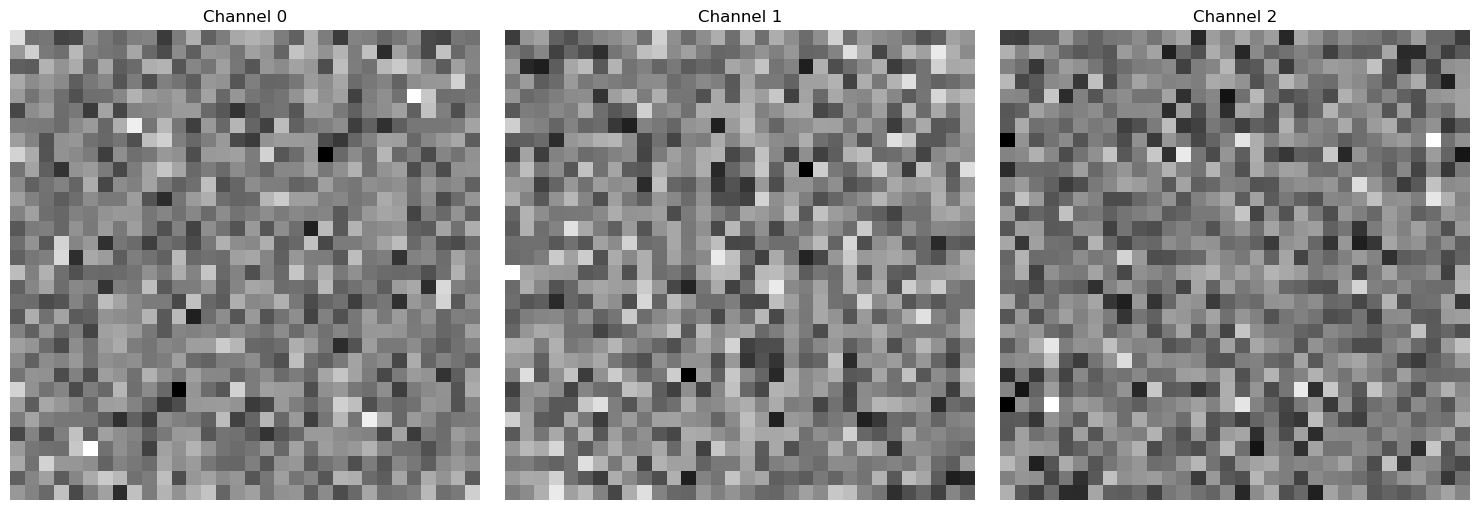

Pattern: zeros


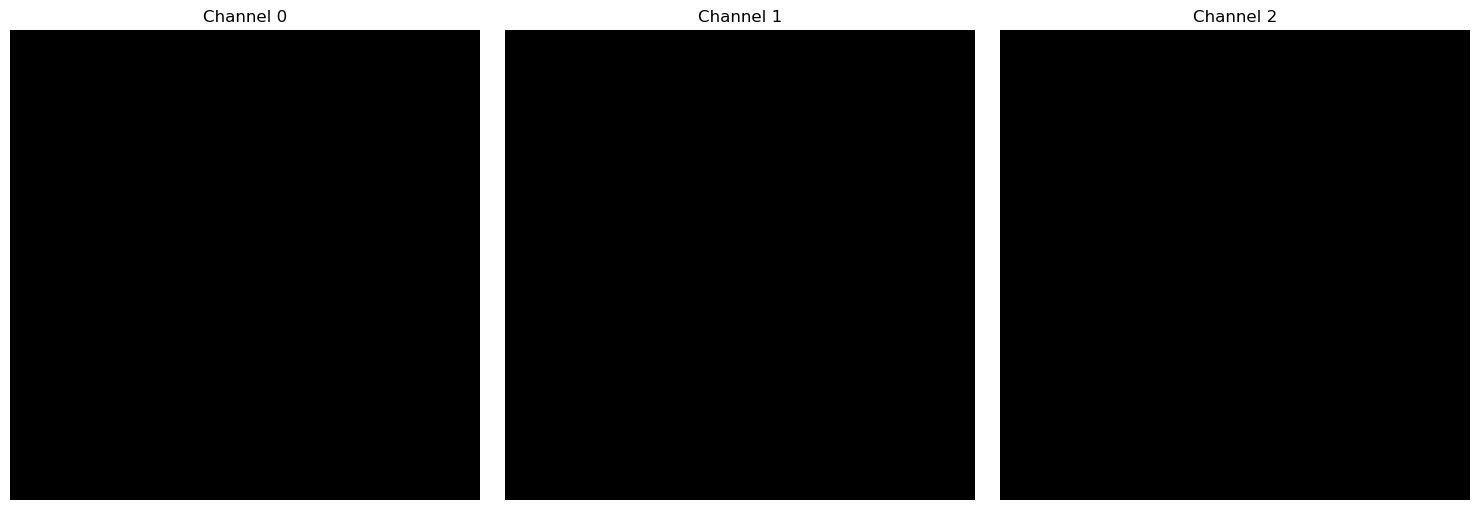

Pattern: const


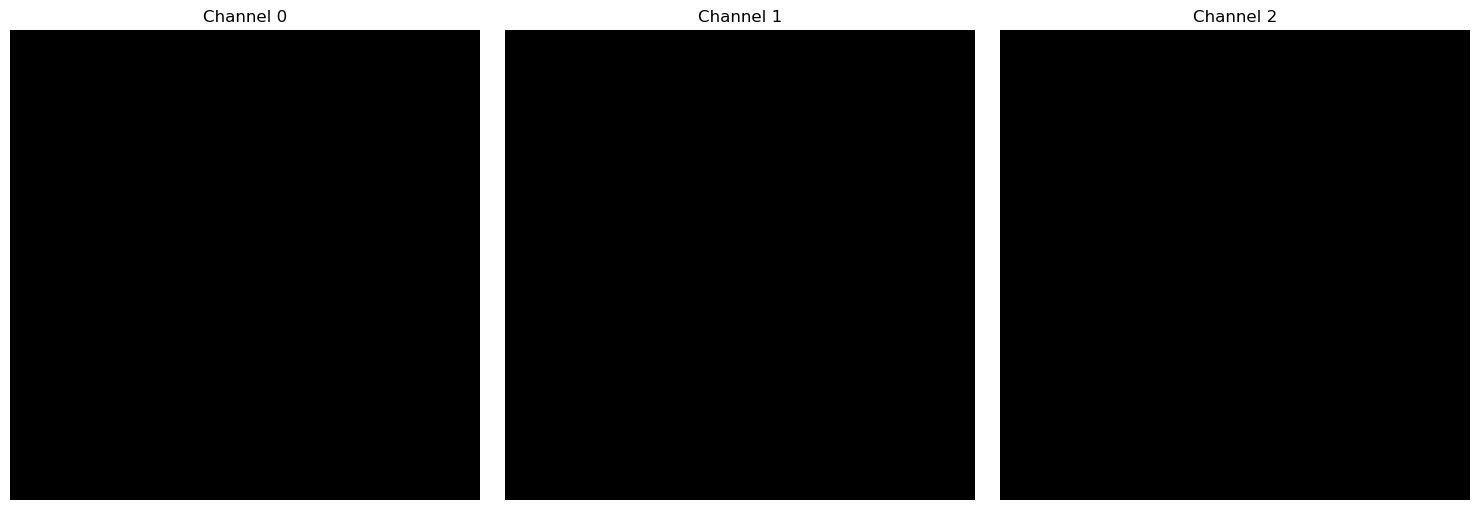

Pattern: seed_rand


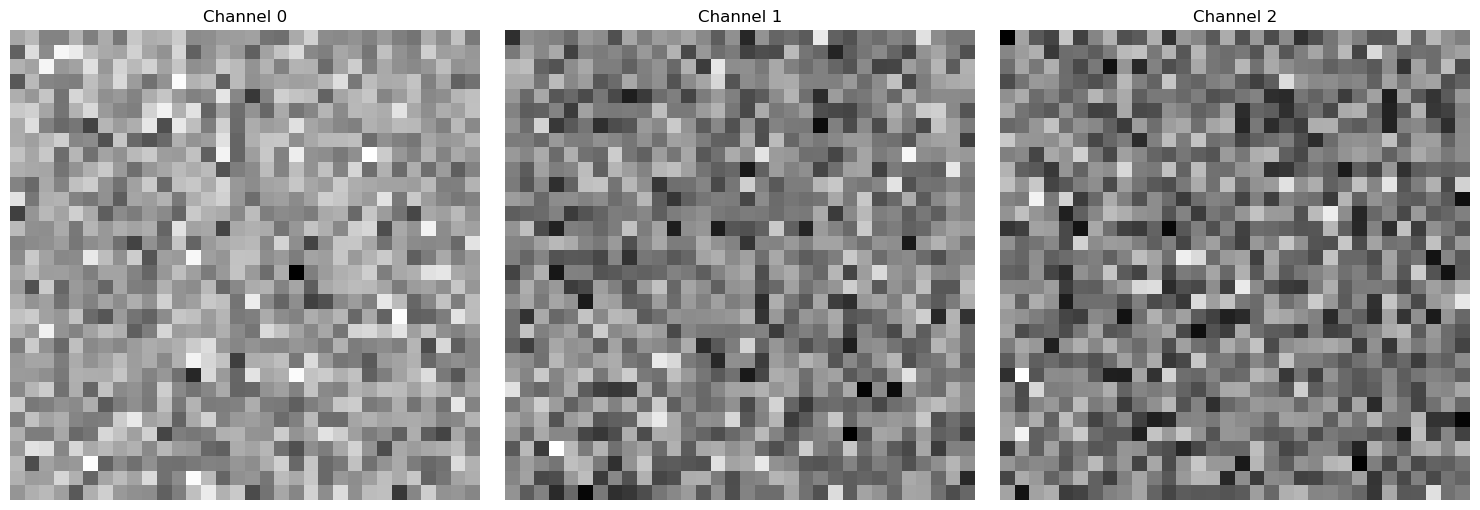

Pattern: seed_zeros


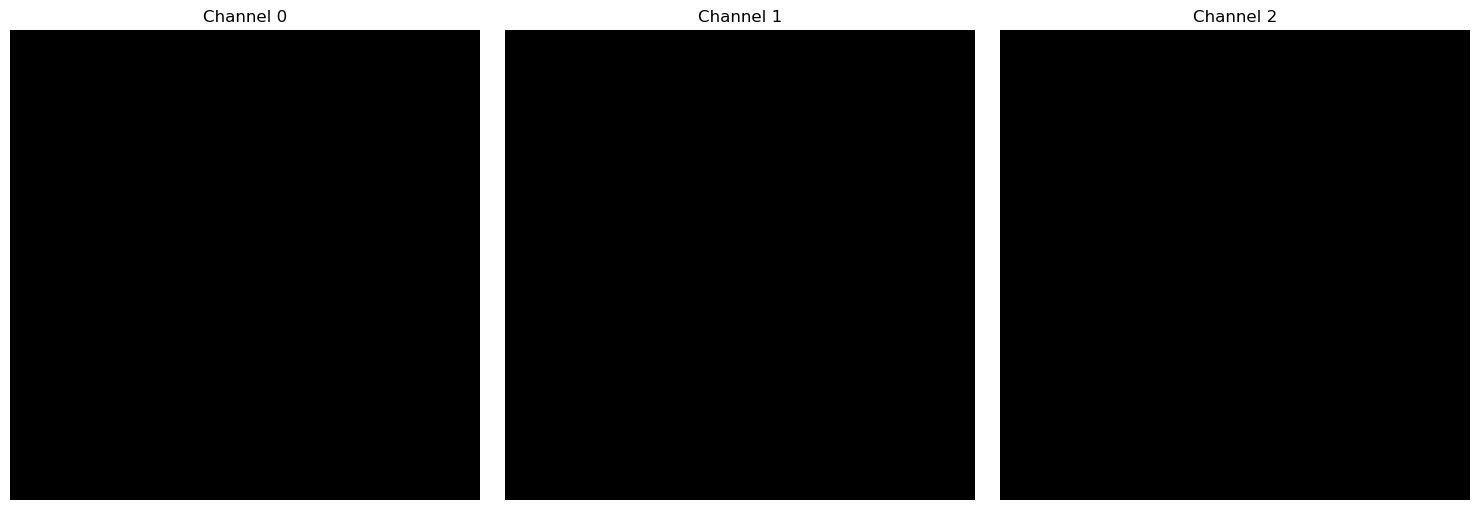

Pattern: seed_ring


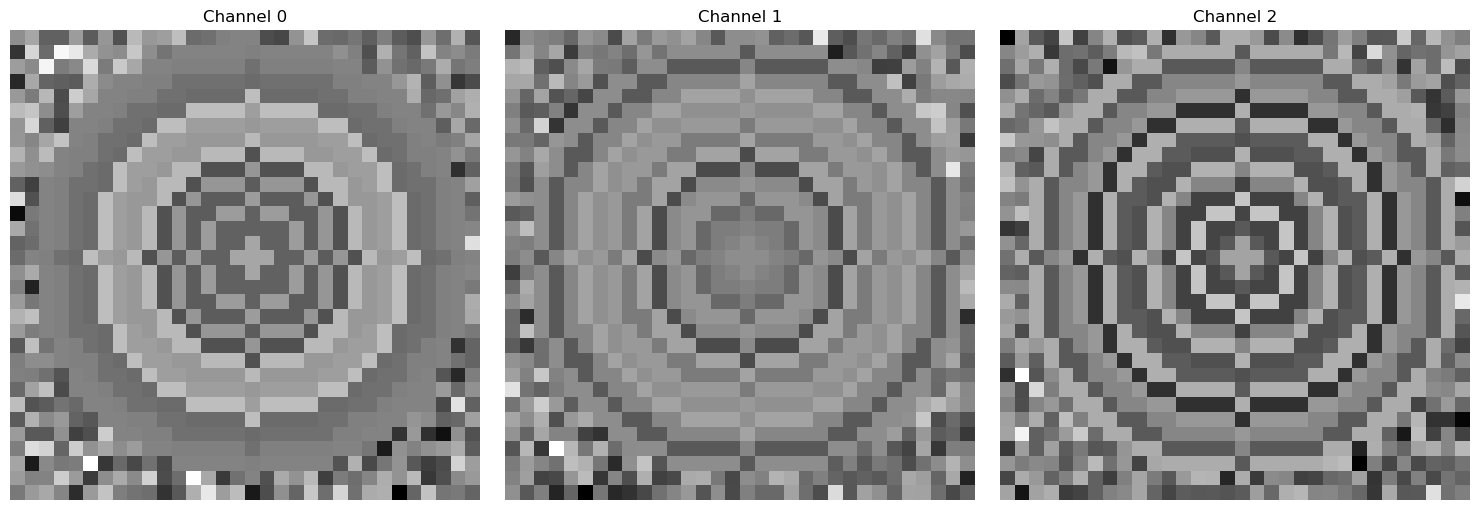

Pattern: ring


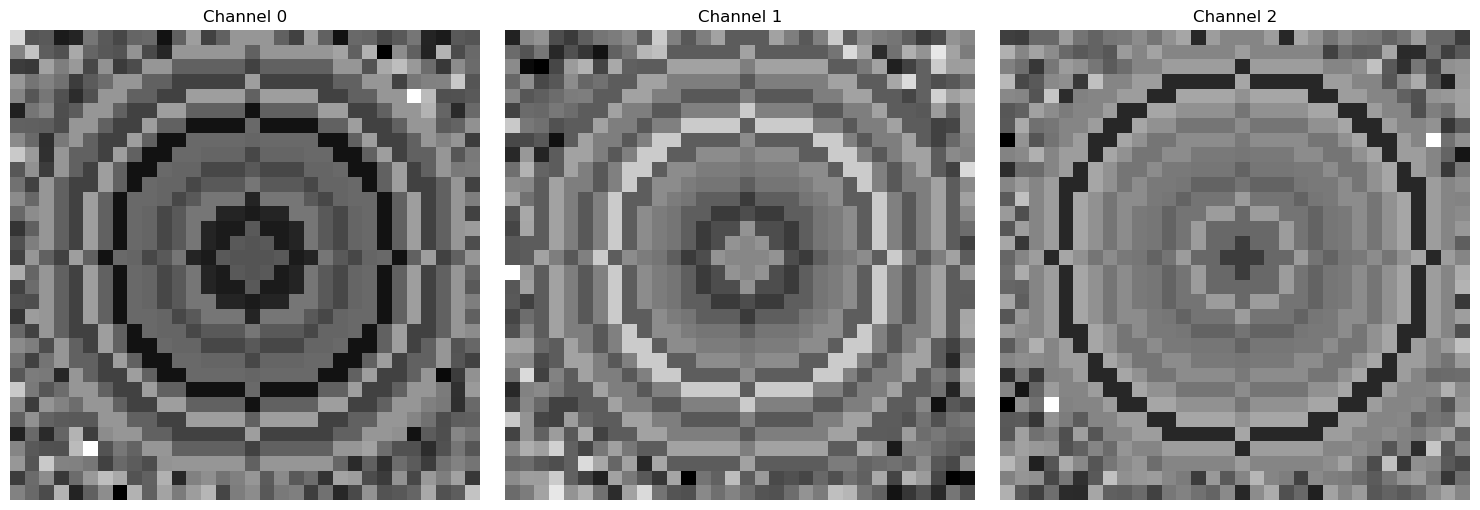

In [10]:
# Visualisation


def visualise_noise(x):
    """
    Visualize the noise or pattern.
    """
    # Convert the tensor to a numpy array and move it to CPU
    x_np = x.real.cpu().numpy()

    fig, axes = plt.subplots(1, x_np.shape[0], figsize=(x_np.shape[0] * 5, 5))
    for idx, ax in enumerate(axes):
        ax.imshow(x_np[idx], cmap="gray")
        ax.set_title(f"Channel {idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


for w_pattern in [
    "rand",
    "zeros",
    "const",
    "seed_rand",
    "seed_zeros",
    "seed_ring",
    "ring",
]:
    print(f"Pattern: {w_pattern}")
    vis_patch = get_watermarking_pattern(
        pipe,
        w_seed=cfg.w_seed,
        w_pattern=w_pattern,
        w_radius=cfg.w_radius,
        device=device,
        shape=None,
    )
    visualise_noise(vis_patch[0])

100%|██████████| 250/250 [00:04<00:00, 52.89it/s]


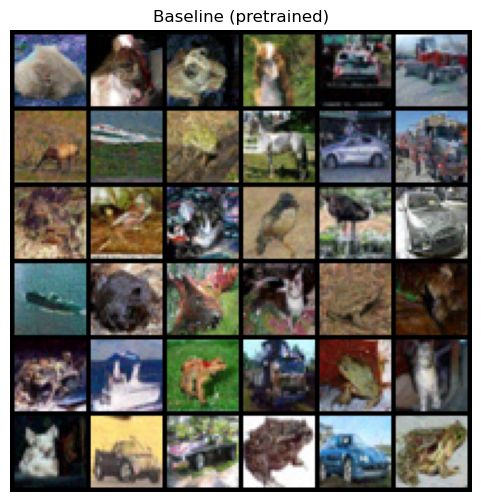

In [11]:
# ====================================================
# Show generation from baseline model
# ====================================================

def _to01(x: torch.Tensor) -> torch.Tensor:
    """
    Normalize to [0,1] for display/uint8 conversion.
    Accepts [..., C, H, W]. If values look like [-1,1], remap; else just clamp [0,1].
    """
    x = x.detach()
    # treat as [-1,1] if it clearly spans beyond [0,1]
    if (x.min().item() < -0.05) or (x.max().item() > 1.05):
        x = (x.clamp(-1, 1) + 1) * 0.5
    return x.clamp(0, 1)

def show_grid_tensor(imgs: torch.Tensor, title: str = "", nrow: int = None, figsize=6):
    """
    Display a grid given a 4D tensor (B,C,H,W) in either [-1,1] or [0,1].
    - Auto-normalizes to [0,1]
    - Chooses a square-ish grid if nrow is not provided
    """
    assert imgs.dim() == 4, "imgs must be [B,C,H,W]"
    B = imgs.size(0)
    if nrow is None:
        nrow = int(math.ceil(math.sqrt(B)))
    grid = make_grid(_to01(imgs), nrow=nrow, padding=2)
    npimg = (grid.cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    plt.figure(figsize=(figsize, figsize) if isinstance(figsize, (int, float)) else figsize)
    plt.imshow(npimg)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

@torch.no_grad()
def sample_pretrained(pipe, num=36, steps=250):
    """Sample from the pretrained model for qualitative visualization."""
    out = pipe(batch_size=num, num_inference_steps=steps)
    arr = []
    for im in out.images:
        arr.append(torch.from_numpy(np.array(im).astype("float32")/255.0).permute(2,0,1))
    return torch.stack(arr, dim=0)

baseline_imgs = sample_pretrained(pipe, num=cfg.n_final_samples, steps=250)
show_grid_tensor(baseline_imgs, "Baseline (pretrained)")

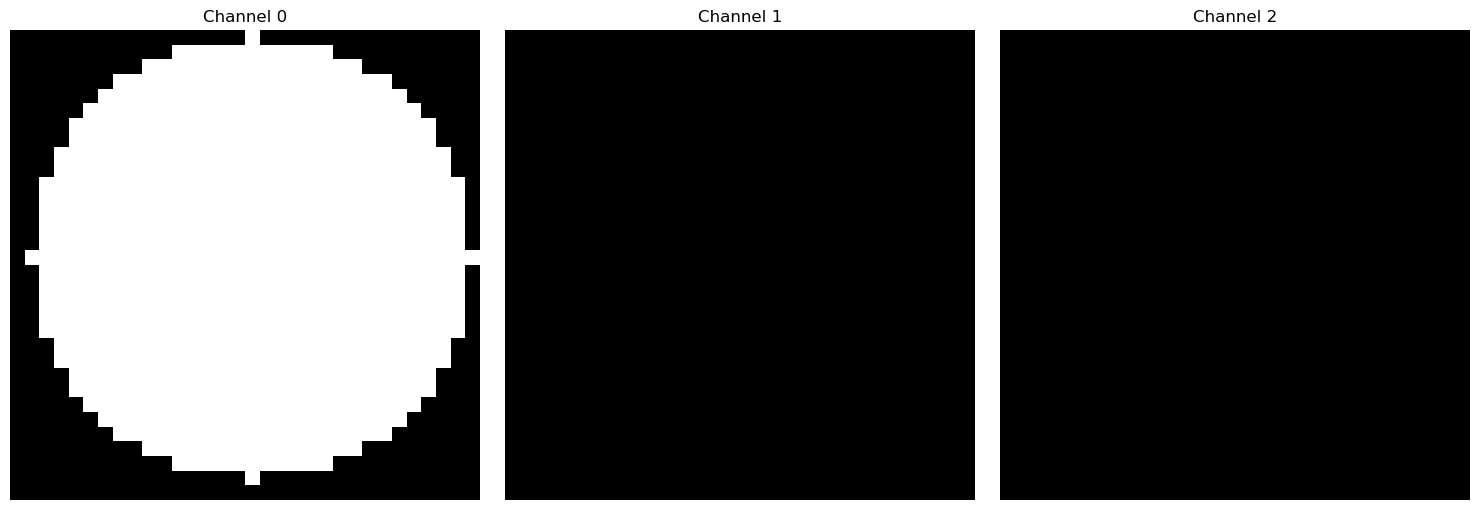

In [12]:
def get_watermarking_mask(
    init_latents_w,
    w_mask_shape: str,
    w_channel: int,
    w_radius: float,
    device: str,
):
    """
    Generate a watermarking mask based on the specified parameters.
    Parameters:
        - init_latents_w: The initial latents with watermarking.
        - w_mask_shape: The shape of the watermarking mask (e.g., "circle", "square").
        - w_channel: The channel to apply the watermarking mask to (-1 for all channels).
        - w_radius: The radius for the watermarking mask.
        - device: The device to use for computation (e.g., "cuda" or "cpu").
    Returns:
        - watermarking_mask: The generated watermarking mask.
    """
    watermarking_mask = torch.zeros(init_latents_w.shape, dtype=torch.bool).to(device)

    if w_mask_shape == "circle":
        np_mask = circle_mask(init_latents_w.shape[-1], r=w_radius)
        torch_mask = torch.tensor(np_mask).to(device)

        if w_channel == -1:
            # all channels
            watermarking_mask[:, :] = torch_mask
        else:
            watermarking_mask[:, w_channel] = torch_mask
    elif w_mask_shape == "square":
        anchor_p = init_latents_w.shape[-1] // 2
        if w_channel == -1:
            # all channels
            watermarking_mask[
                :,
                :,
                anchor_p - w_radius : anchor_p + w_radius,
                anchor_p - w_radius : anchor_p + w_radius,
            ] = True
        else:
            watermarking_mask[
                :,
                w_channel,
                anchor_p - w_radius : anchor_p + w_radius,
                anchor_p - w_radius : anchor_p + w_radius,
            ] = True
    elif w_mask_shape == "no":
        pass
    else:
        raise NotImplementedError(f"w_mask_shape: {w_mask_shape}")

    return watermarking_mask

# Use the same latent for generating the image with watermark
set_random_seed(cfg.seed)
init_latents_w = pipe.get_random_latents()
watermarking_mask = get_watermarking_mask(
    init_latents_w,
    w_mask_shape=cfg.w_mask_shape,
    w_channel=cfg.w_channel,
    w_radius=cfg.w_radius, 
    device=device,
)
visualise_noise(watermarking_mask[0].float()) 

In [13]:
def inject_watermark(init_latents_w, watermarking_mask, gt_patch, w_injection: str):
    """
    Inject the watermark into the latents.
    Parameters:
        - init_latents_w: The initial latents with watermarking.
        - watermarking_mask: The mask indicating where to inject the watermark. (in the Fourier domain)
        - gt_patch: The watermark pattern to be injected.
        - w_injection: The method of watermark injection (e.g., "complex", "seed").
    Returns:
        - init_latents_w: The latents with the watermark injected.
    """
    # Perform FFT on the latents
    init_latents_w_fft = torch.fft.fftshift(torch.fft.fft2(init_latents_w), dim=(-1, -2))

    # Inject the watermark into the latents in FFT domain
    if w_injection == 'complex':
        init_latents_w_fft[watermarking_mask] = gt_patch[watermarking_mask].clone()
    elif w_injection == 'seed':
        init_latents_w[watermarking_mask] = gt_patch[watermarking_mask].clone()
        return init_latents_w
    else:
        NotImplementedError(f'w_injection: {w_injection}')

    # Perform inverse FFT to get the latents with watermark
    init_latents_w = torch.fft.ifft2(torch.fft.ifftshift(init_latents_w_fft, dim=(-1, -2))).real

    return init_latents_w

init_latents_w = inject_watermark(
    init_latents_w,
    watermarking_mask,
    gt_patch,
    w_injection=cfg.w_injection,
)

100%|██████████| 250/250 [00:03<00:00, 80.80it/s]


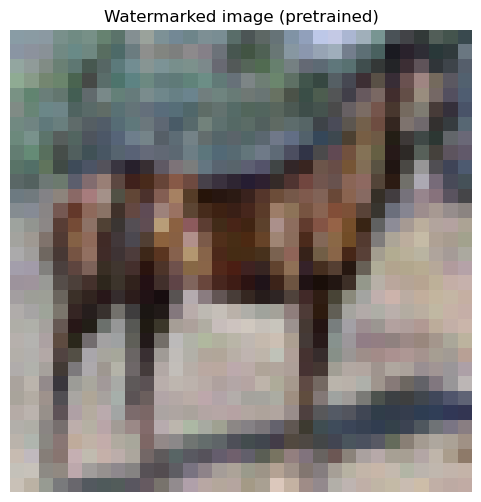

In [14]:
tr_img = pipe(
    num_inference_steps=250,
    latents=init_latents_w,
)
# show the image

tr_img_tsr = torch.stack([transforms.ToTensor()(im) for im in tr_img.images], dim=0).to(device)
show_grid_tensor(tr_img_tsr, "Watermarked image (pretrained)")

In [ ]:
# ====================================================
# Verification Test
# ====================================================

def transform_img(image, target_size=512):
    tform = transforms.Compose(
        [
            transforms.Resize(target_size),
            transforms.CenterCrop(target_size),
            transforms.ToTensor(),
        ]
    )
    image = tform(image)
    return 2.0 * image - 1.0

# image_latents = pipe.get_image_latents(tr_img_tsr, sample=False)
reversed_latents = pipe.forward_diffusion(
    image=image,
    guidance_scale=1,
    num_inference_steps=cfg.sample_steps,
)


In [ ]:
import torch
import math

def _compute_psnr_masked(pred, target, mask, eps=1e-8):
    """
    Fallback PSNR on masked region: 10*log10(MAX^2 / MSE_masked).
    Assumes inputs in [0,1] or any bounded range; uses dynamic MAX from target.
    """
    # restrict to mask
    diff = (pred - target)[mask]
    mse = (diff.float() ** 2).mean().clamp_min(eps)
    # dynamic range from target over mask
    t = target[mask].float()
    max_val = (t.max() - t.min()).clamp_min(eps)
    # if target is constant, fall back to 1.0 range
    if max_val.item() == 0.0:
        max_val = torch.tensor(1.0, device=t.device)
    psnr = 10.0 * torch.log10((max_val ** 2) / mse)
    return psnr.item()

def eval_watermark(
    latent: torch.Tensor,
    watermarking_mask: torch.Tensor,
    gt_patch: torch.Tensor,
    w_measurement: str,
) -> float:
    """
    Evaluate watermark quality for a SINGLE latent against gt_patch on watermarking_mask.

    Args:
        latent:              Tensor [..., H, W] or [..., C, H, W] (last two dims are H,W).
        watermarking_mask:   Bool/byte mask broadcastable to latent/gt_patch spatial dims.
        gt_patch:            Ground-truth pattern tensor, same shape as latent (or broadcastable).
        w_measurement:       e.g. "complex+l1", "seed+l1", "complex+psnr", "seed+psnr".

    Returns:
        metric: float scalar.
    """
    # choose domain
    if "complex" in w_measurement:
        # FFT over spatial dims (H, W); shift to center
        latent_dom = torch.fft.fftshift(torch.fft.fft2(latent), dim=(-1, -2))
        target_dom = gt_patch
    elif "seed" in w_measurement:
        # real domain
        latent_dom = latent
        target_dom = gt_patch
    else:
        raise NotImplementedError(f"w_measurement domain not recognized: {w_measurement}")

    # ensure mask is boolean and broadcastable to spatial dims
    wm_mask = watermarking_mask.bool()

    # metric
    if "l1" in w_measurement:
        metric = torch.abs(latent_dom[wm_mask] - target_dom[wm_mask]).mean().item()
    elif "psnr" in w_measurement:
        # try user's compute_psnr first (signature: (pred, target, mask))
        if "compute_psnr" in globals() and callable(globals()["compute_psnr"]):
            metric = globals()["compute_psnr"](latent_dom, target_dom, wm_mask)
        else:
            metric = _compute_psnr_masked(latent_dom, target_dom, wm_mask)
    else:
        raise NotImplementedError(f"w_measurement metric not recognized: {w_measurement}")

    return metric


In [ ]:
def verify(image):
    # visualise the image first
    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    tsr_img = transform_img(image).unsqueeze(0).to(device)
    image_latents = pipe.get_image_latents(tsr_img, sample=False)
    reversed_latents = pipe.forward_diffusion(
        latents=image_latents,
        guidance_scale=1,
        num_inference_steps=cfg.sample_steps,
    )

    # visulise it in the Fourier domain
    vis_latent_fft = torch.fft.fftshift(torch.fft.fft2(reversed_latents), dim=(-1, -2))
    visualise_noise(vis_latent_fft[0].abs())

    l1_metric = eval_watermark(
        reversed_latents,
        watermarking_mask,
        gt_patch,
        w_measurement="l1_complex",
    )

    psnr_metric = eval_watermark(
        reversed_latents,
        watermarking_mask,
        gt_patch,
        w_measurement="psnr_complex",
    )

    print(f"L1 metric: {l1_metric:.4f}, PSNR metric: {psnr_metric:.4f}")

In [27]:
gt_patch.shape

torch.Size([1, 3, 32, 32])

In [29]:
tsr_img = transform_img(tr_img.images[0]).unsqueeze(0).to(device)
image_latents = pipe.get_image_latents(tsr_img, sample=False)
reversed_latents = pipe.forward_diffusion(
    latents=image_latents,
    guidance_scale=1,
    num_inference_steps=cfg.sample_steps,
)


In [30]:
reversed_latents.shape

torch.Size([1, 3, 512, 512])

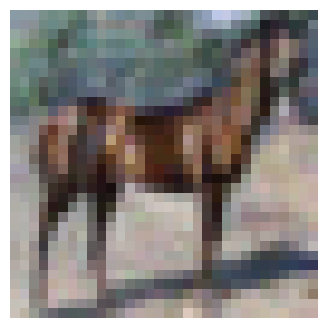

IndexError: The shape of the mask [1, 3, 32, 32] at index 2 does not match the shape of the indexed tensor [1, 3, 512, 512] at index 2

In [ ]:
verify(tr_img.images[0])

In [ ]:
# ====================================================
# Image distortion
# ====================================================

from torchvision import transforms
from PIL import Image, ImageFilter
from attack import Attacker

attacker = Attacker()
attacked_tr_img = attacker.attack(wm_img[0])

# show single attacked_tr_img
fig = plt.figure(figsize=(8, 8))
plt.imshow(attacked_tr_img)
plt.axis("off")
plt.show()

In [ ]:
verify(attacked_tr_img)